# Radon random-restart VI

This notebook implements the PyMC tutorial's varying-intercept radon model for the same random-restart comparison pattern used elsewhere in `single_MC`. The plotted references use the PyMC tutorial's reported beta mean, the saved-output NumPyro-ELBO best beta std, and the saved-output NumPyro-ELBO best reference for the other selected parameters; when `best_reference_values_without_pymc.csv` exists, that non-PyMC reference file is preferred.

Model:

```text
y_i = alpha[county_i] + beta * floor_i + epsilon_i
alpha_j ~ Normal(mu_a, sigma_a)
mu_a ~ Normal(0, 10)
sigma_a ~ Exponential(1)
beta ~ Normal(0, 10)
sd_y ~ Exponential(1)
epsilon_i ~ Normal(0, sd_y)
```

## NumPyro

This version encodes the PyMC tutorial model directly and uses NumPyro `AutoNormal` guide.

In [1]:
import os
import gc
from pathlib import Path
import sys

sys.path.append(os.path.abspath('../../..'))

import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist

from modulars.numpyro_rr_test import run_restart_multid_autonormal
from modulars.radon import build_numpyro_radon_model

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

from modulars.plot_rr import plot_some_dims_multid
from modulars.radon import (
    load_best_references,
    print_reference_summary,
    default_radon_plot_dims,
    load_radon_data,
    make_radon_unconstrained_param_names,
    plot_radon_selected_dims,
)
from modulars.utils import apply_traj_transform_multid, save_to_csv

radon_data = load_radon_data()
county_names = radon_data['county_names']
param_names = make_radon_unconstrained_param_names(county_names)
dim = len(param_names)
which_dims, which_labels = default_radon_plot_dims(param_names, county_names)
site_names = ('mu_a', 'sigma_a', 'alpha', 'beta', 'sd_y')

print(f"N observations: {len(radon_data['log_radon'])}")
print(f"N counties: {len(county_names)}")
print(f"Latent VI dimension: {dim}")
print(list(zip(which_dims, which_labels)))


N observations: 919
N counties: 85
Latent VI dimension: 89
[(0, 'mu_a'), (87, 'beta'), (27, 'alpha[HENNEPIN]'), (71, 'alpha[ST LOUIS]')]


In [2]:
# Toggle this before running the notebook.
# "quick" keeps the 100-MC comparison but shortens the run for smoke checks.
# "full" is the research-run setting used for the planned comparison.
RUN_MODE = "full"  # "quick" or "full"

RUN_CONFIGS = {
    "quick": {"max_iters": 250, "n_restarts": 1, "n_particles": 100, "track_every": 10, "save_raw": False},
    "full": {"max_iters": 40_000, "n_restarts": 10, "n_particles": 100, "track_every": 10, "save_raw": False},
}

run_config = RUN_CONFIGS[RUN_MODE]
max_iters = run_config["max_iters"]
n_restarts = run_config["n_restarts"]
n_particles = run_config["n_particles"]
track_every = run_config["track_every"]
save_raw = run_config.get("save_raw", False)

results_dir = Path("results")
results_dir.mkdir(exist_ok=True)

run_config


{'max_iters': 40000,
 'n_restarts': 10,
 'n_particles': 100,
 'track_every': 10,
 'save_raw': False}

In [8]:
print_reference_summary()
reference_summary, best_reference, reference_means, reference_stds = load_best_references()

print(reference_means['mu_a'])
print(reference_summary)

PyMC tutorial exact reported summaries:
{'beta': {'mean': -0.664, 'sd': 0.069}}

Reference notes:
- pymc_tutorial: The notebooks implement the PyMC tutorial's centered varying-intercept model: county intercepts, a shared floor effect, and Exponential(1) priors on the positive scale parameters.
- best_advi_reference: Parameters not reported directly by the PyMC tutorial are compared against the shared saved-output VI reference in best_reference_values.csv. The reference script selects the saved 100-MC variational restart with the largest NumPyro-computed fixed-guide ELBO.
- price_nero_gelman_1996: The peer-reviewed Price/Nero/Gelman Health Physics article uses a different county-geometric-mean model on adjusted Bq/m^3 radon values; those comparisons live in single_MC/radon_example/price_nero_gelman_1996.
[(1.4921311140060425, 'Saved VI NumPyro-ELBO best (pymc default_100_mc restart 0)')]
                        source              model parameter summary  value  \
0  PyMC latest example

In [4]:
model = build_numpyro_radon_model()
model_args = (
    radon_data['log_radon'],
    radon_data['floor'],
    radon_data['log_uranium'],
    radon_data['county'],
    radon_data['floor_by_county'],
)


In [ ]:
results = []
for seed in tqdm(range(n_restarts)):
    result = run_restart_multid_autonormal(
        seed=seed,
        model=model,
        data=None,
        param_name='radon_latent',
        n_iters=max_iters,
        dim=dim,
        n_particles=n_particles,
        model_args=model_args,
        site_names=site_names,
        track_every=track_every,
    )
    results.append(result)
    gc.collect()


In [ ]:
if save_raw:
    save_to_csv(results_dir / "numpyro_raw_restarts.csv", results)


In [ ]:
single_means, single_stds, multi_means, multi_stds = apply_traj_transform_multid(results)
print(single_means.shape, single_stds.shape, multi_means.shape, multi_stds.shape)

del results
gc.collect()


In [ ]:
save_to_csv(
    results_dir / "numpyro_processed_restarts.csv",
    [(single_means, single_stds, multi_means, multi_stds)],
)
save_to_csv(
    results_dir / "numpyro_final_restarts.csv",
    [(multi_means[:, -1, :], multi_stds[:, -1, :])],
)


In [5]:
# load from csv
from modulars.utils import load_from_csv
processed_path = results_dir / "numpyro_processed_restarts.csv"
if processed_path.exists():
    loaded = load_from_csv(processed_path)
    single_means, single_stds, multi_means, multi_stds = loaded[0]

In [ ]:
# for editing plotting in the middle
import importlib
import modulars.radon
importlib.reload(modulars.radon)

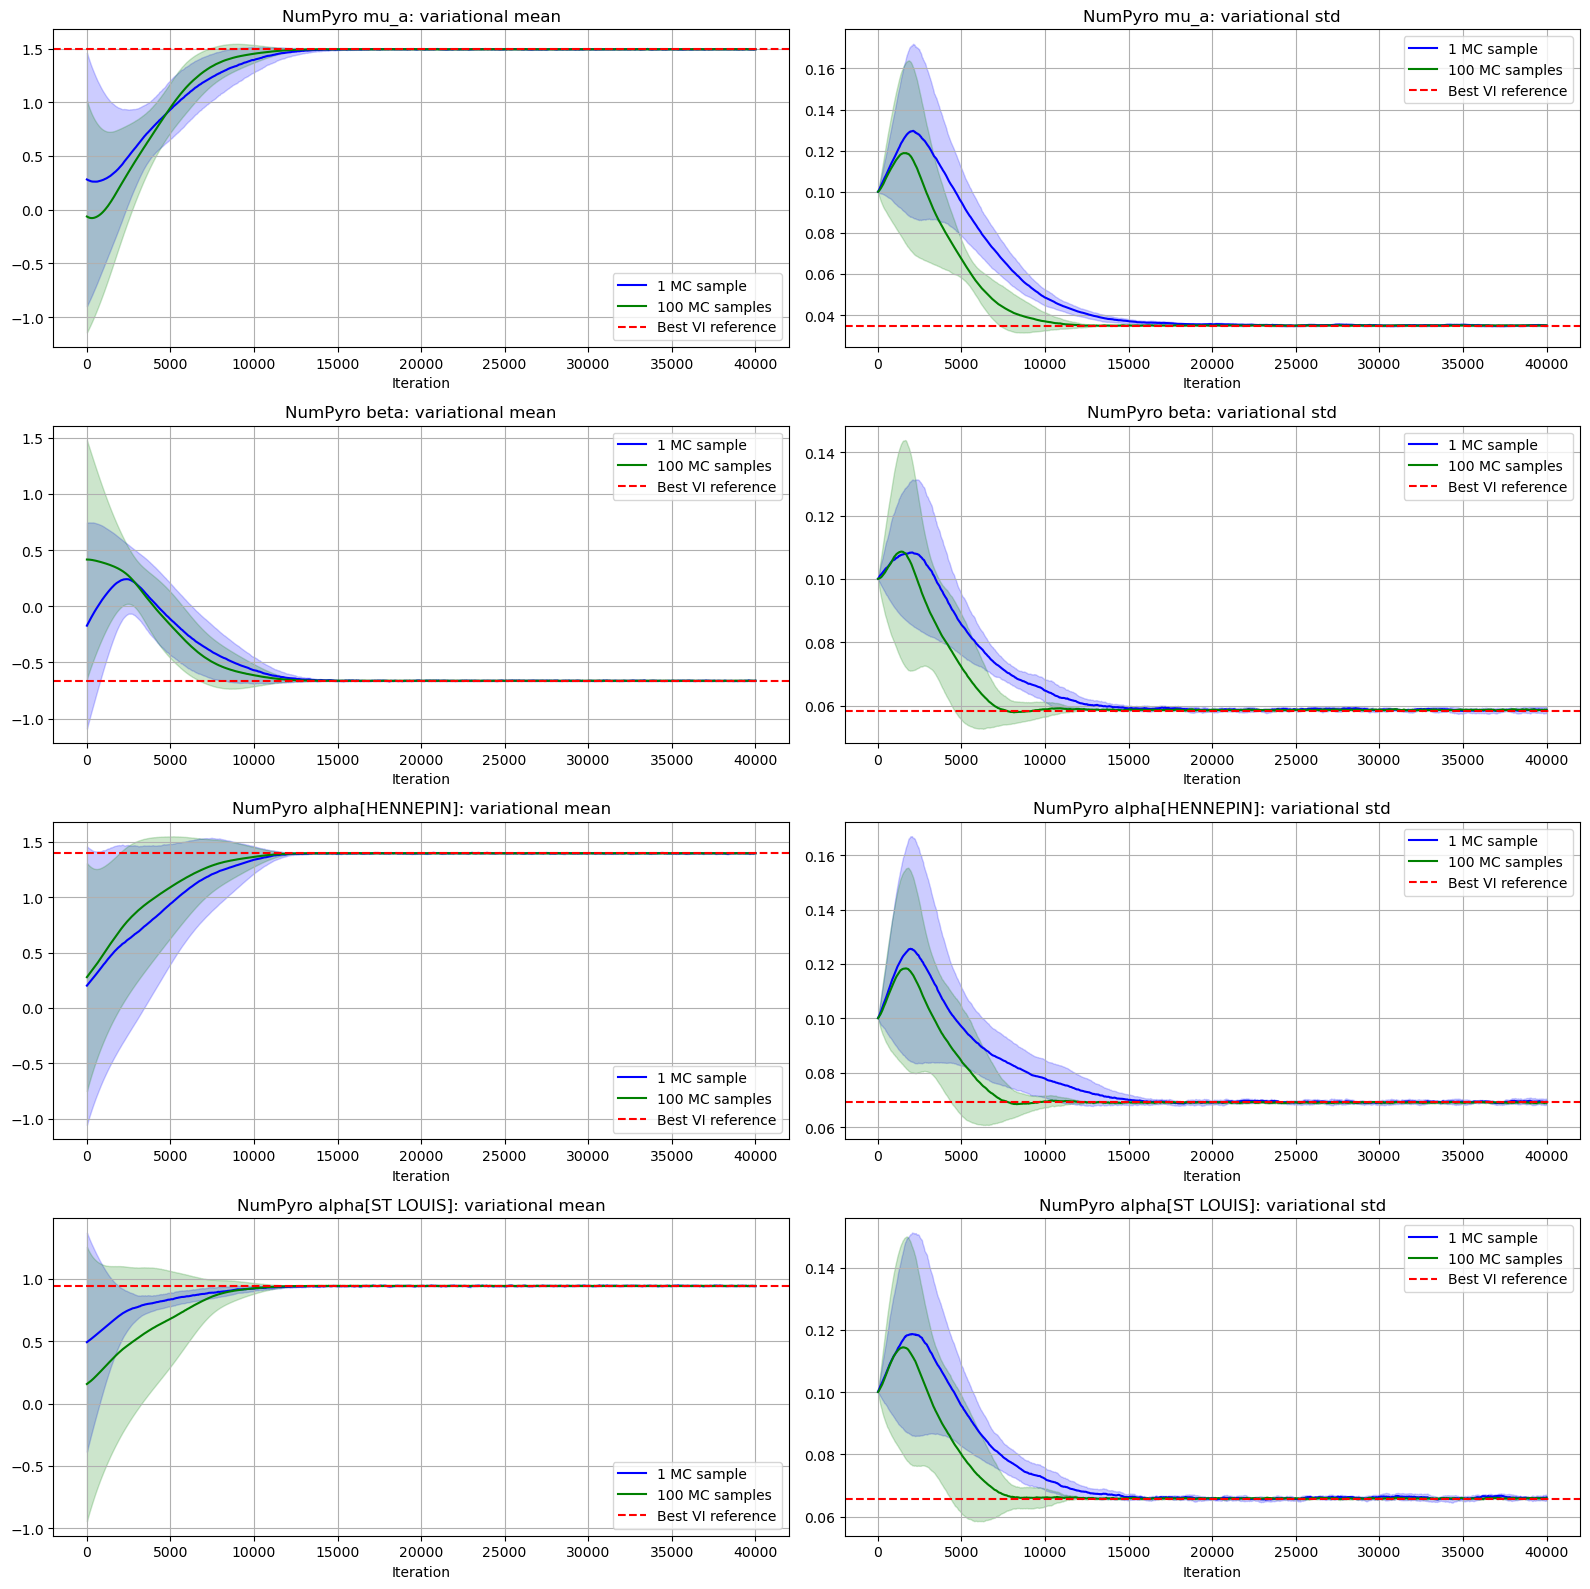

In [9]:
plot_radon_selected_dims(
    single_means, single_stds, multi_means, multi_stds,
    which_dims, which_labels,
    title_prefix='NumPyro ',
    reference_means=reference_means,
    reference_stds=reference_stds,
    iteration_stride=track_every,
)


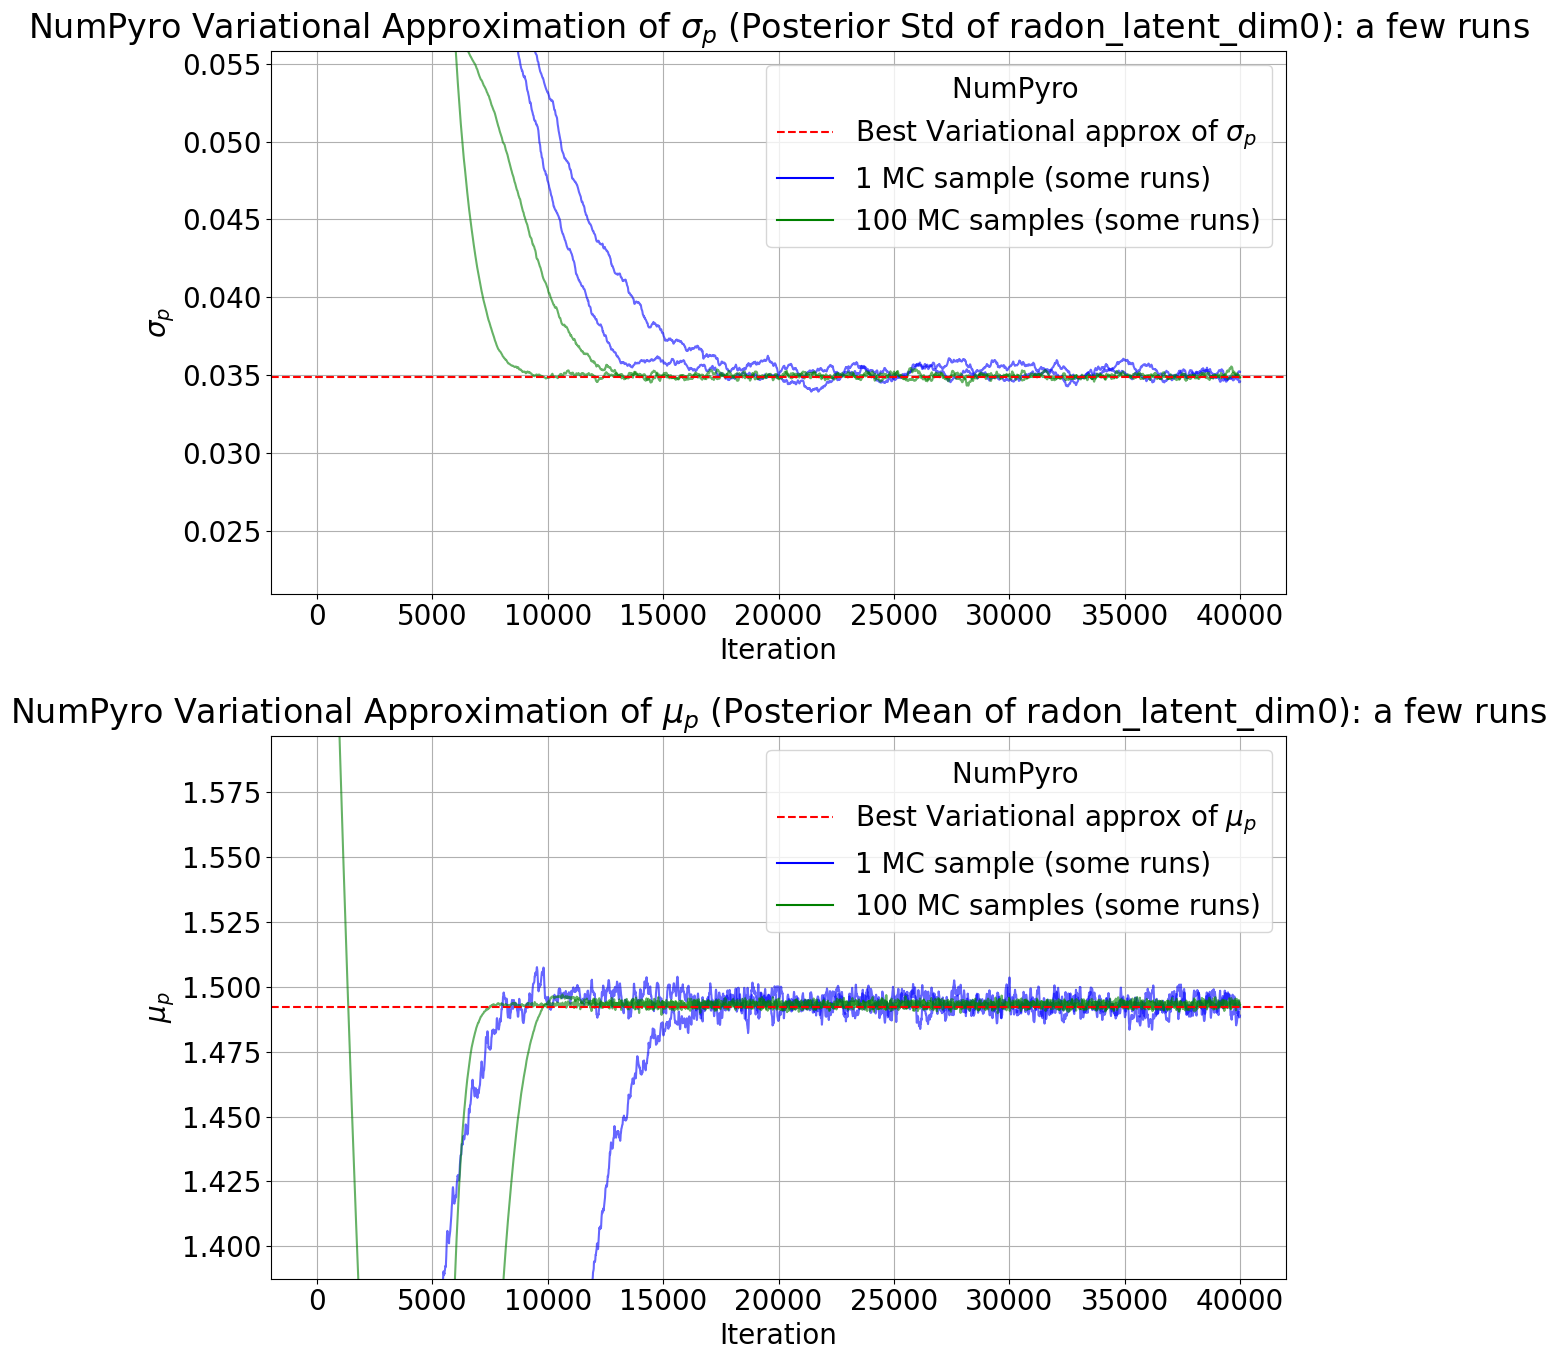

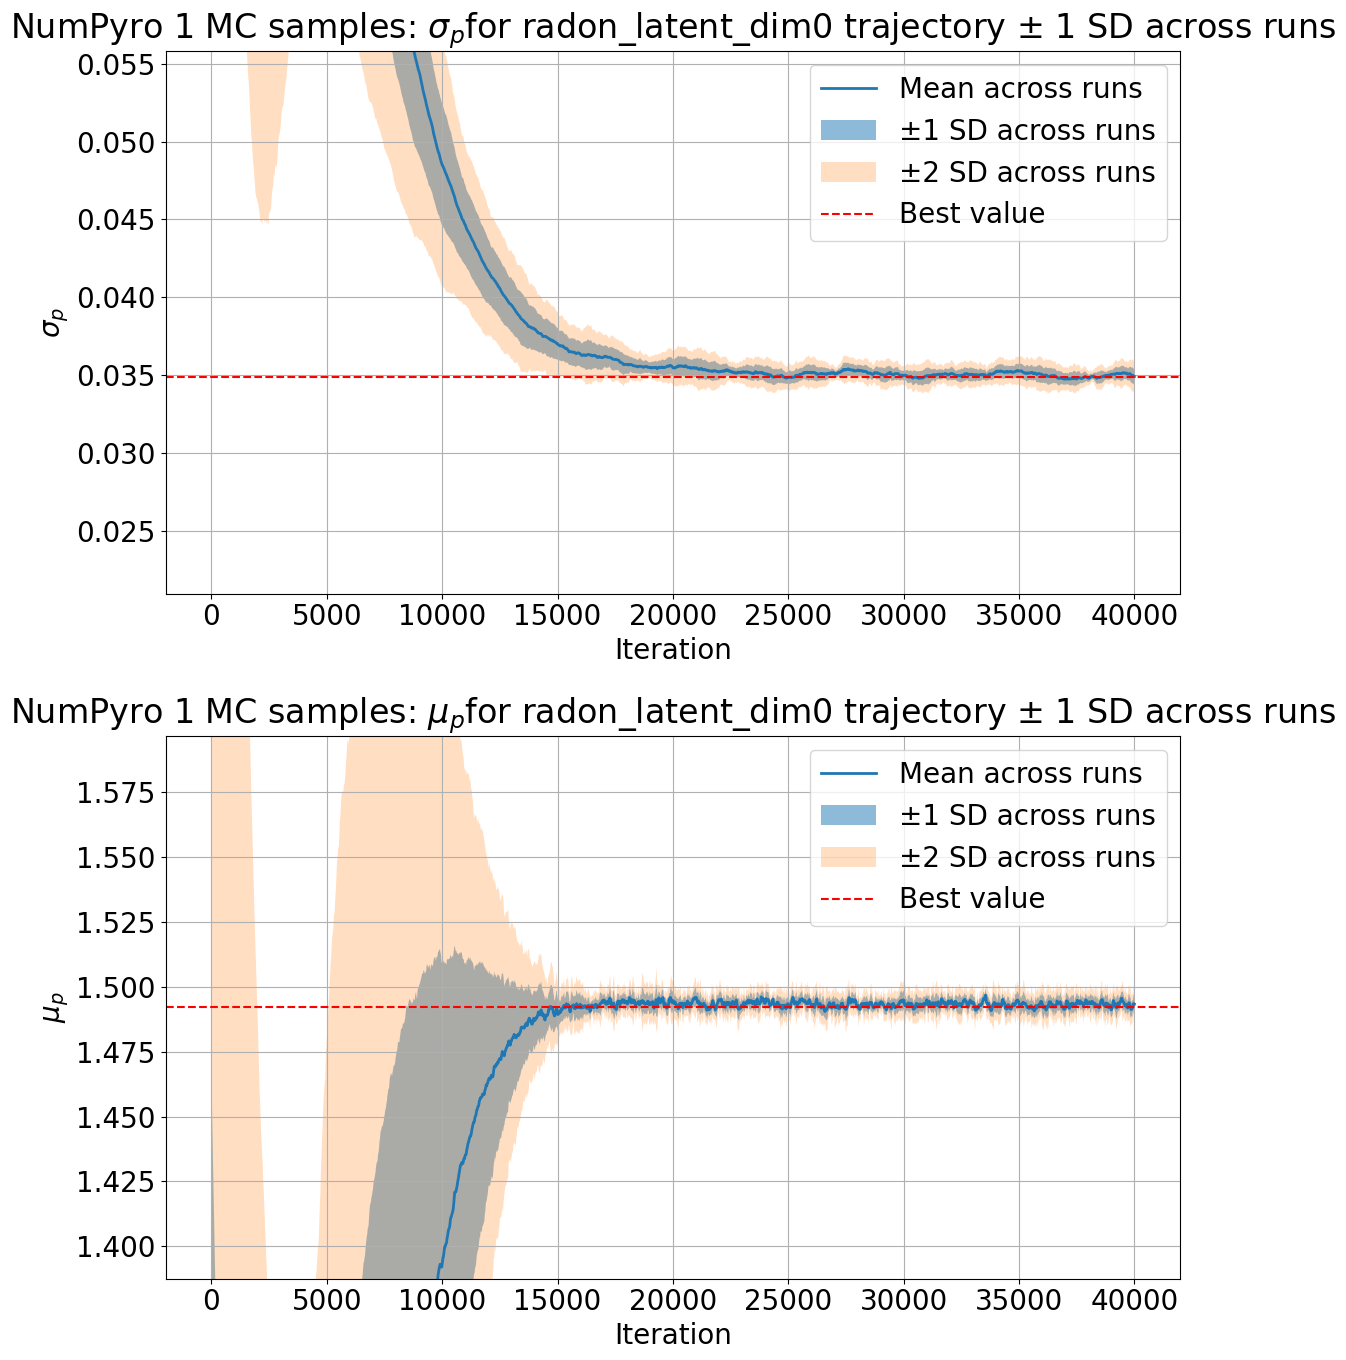

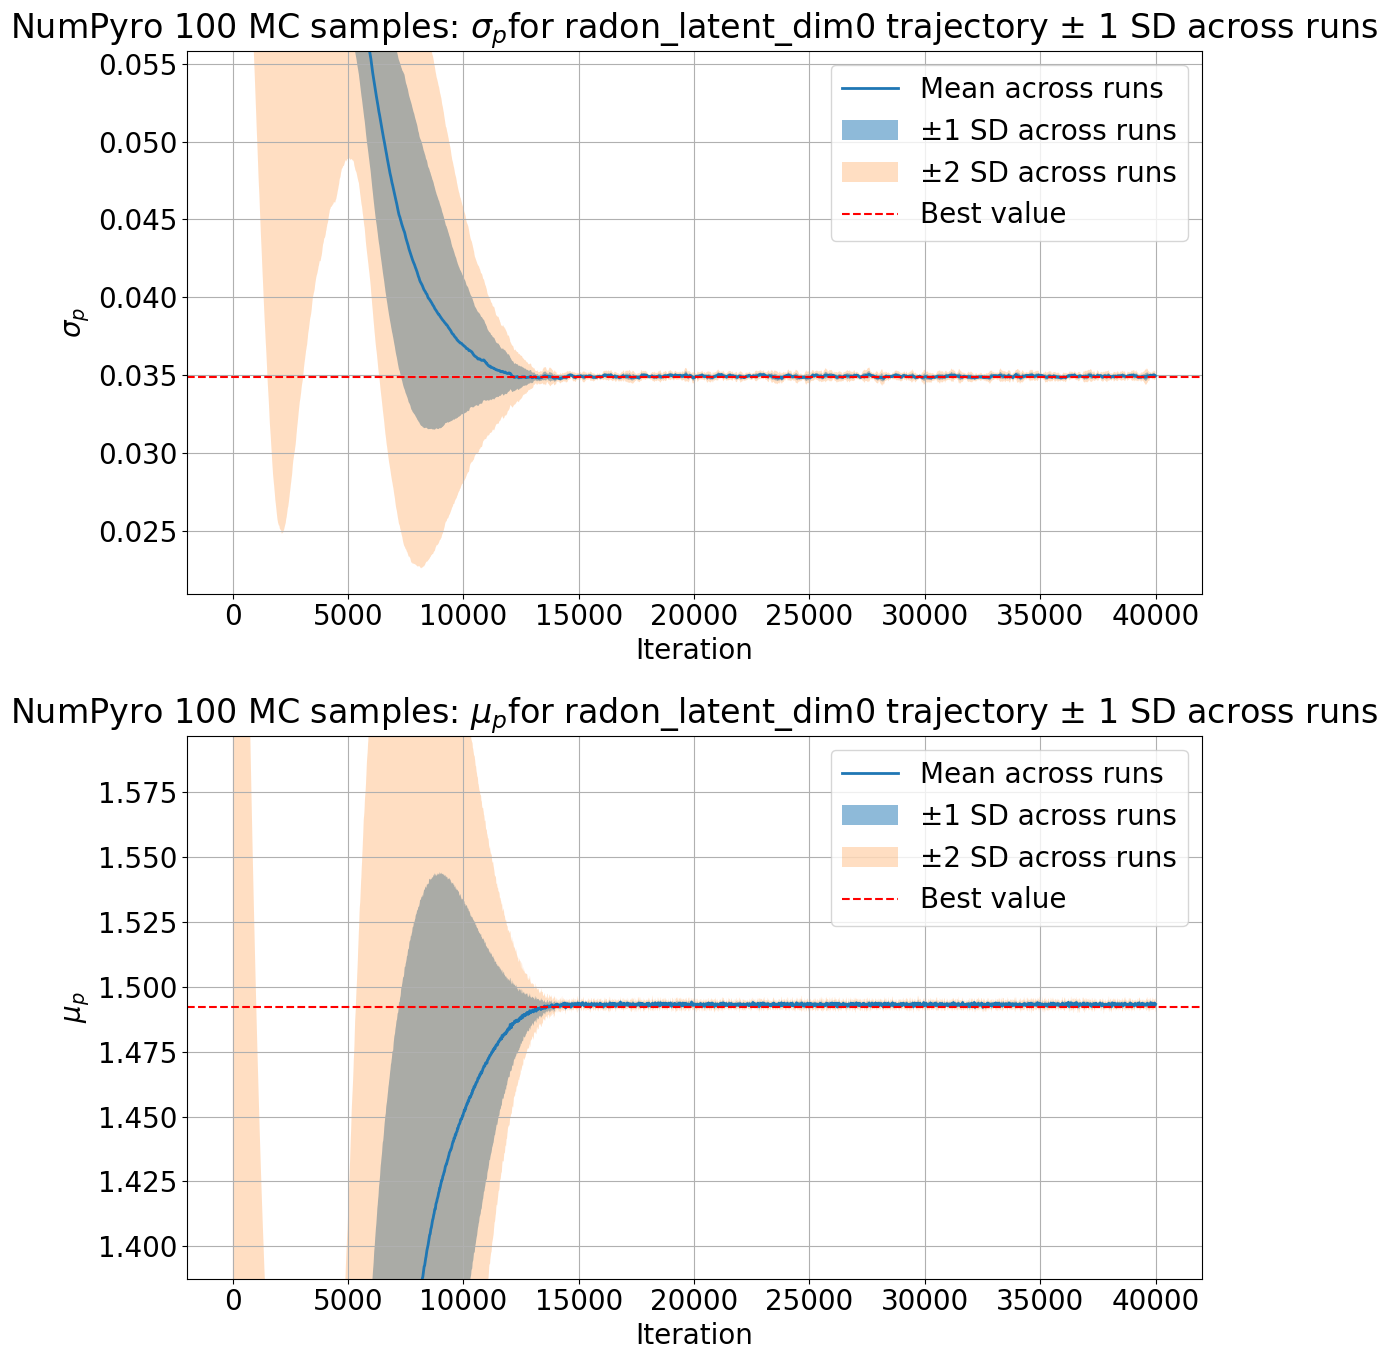

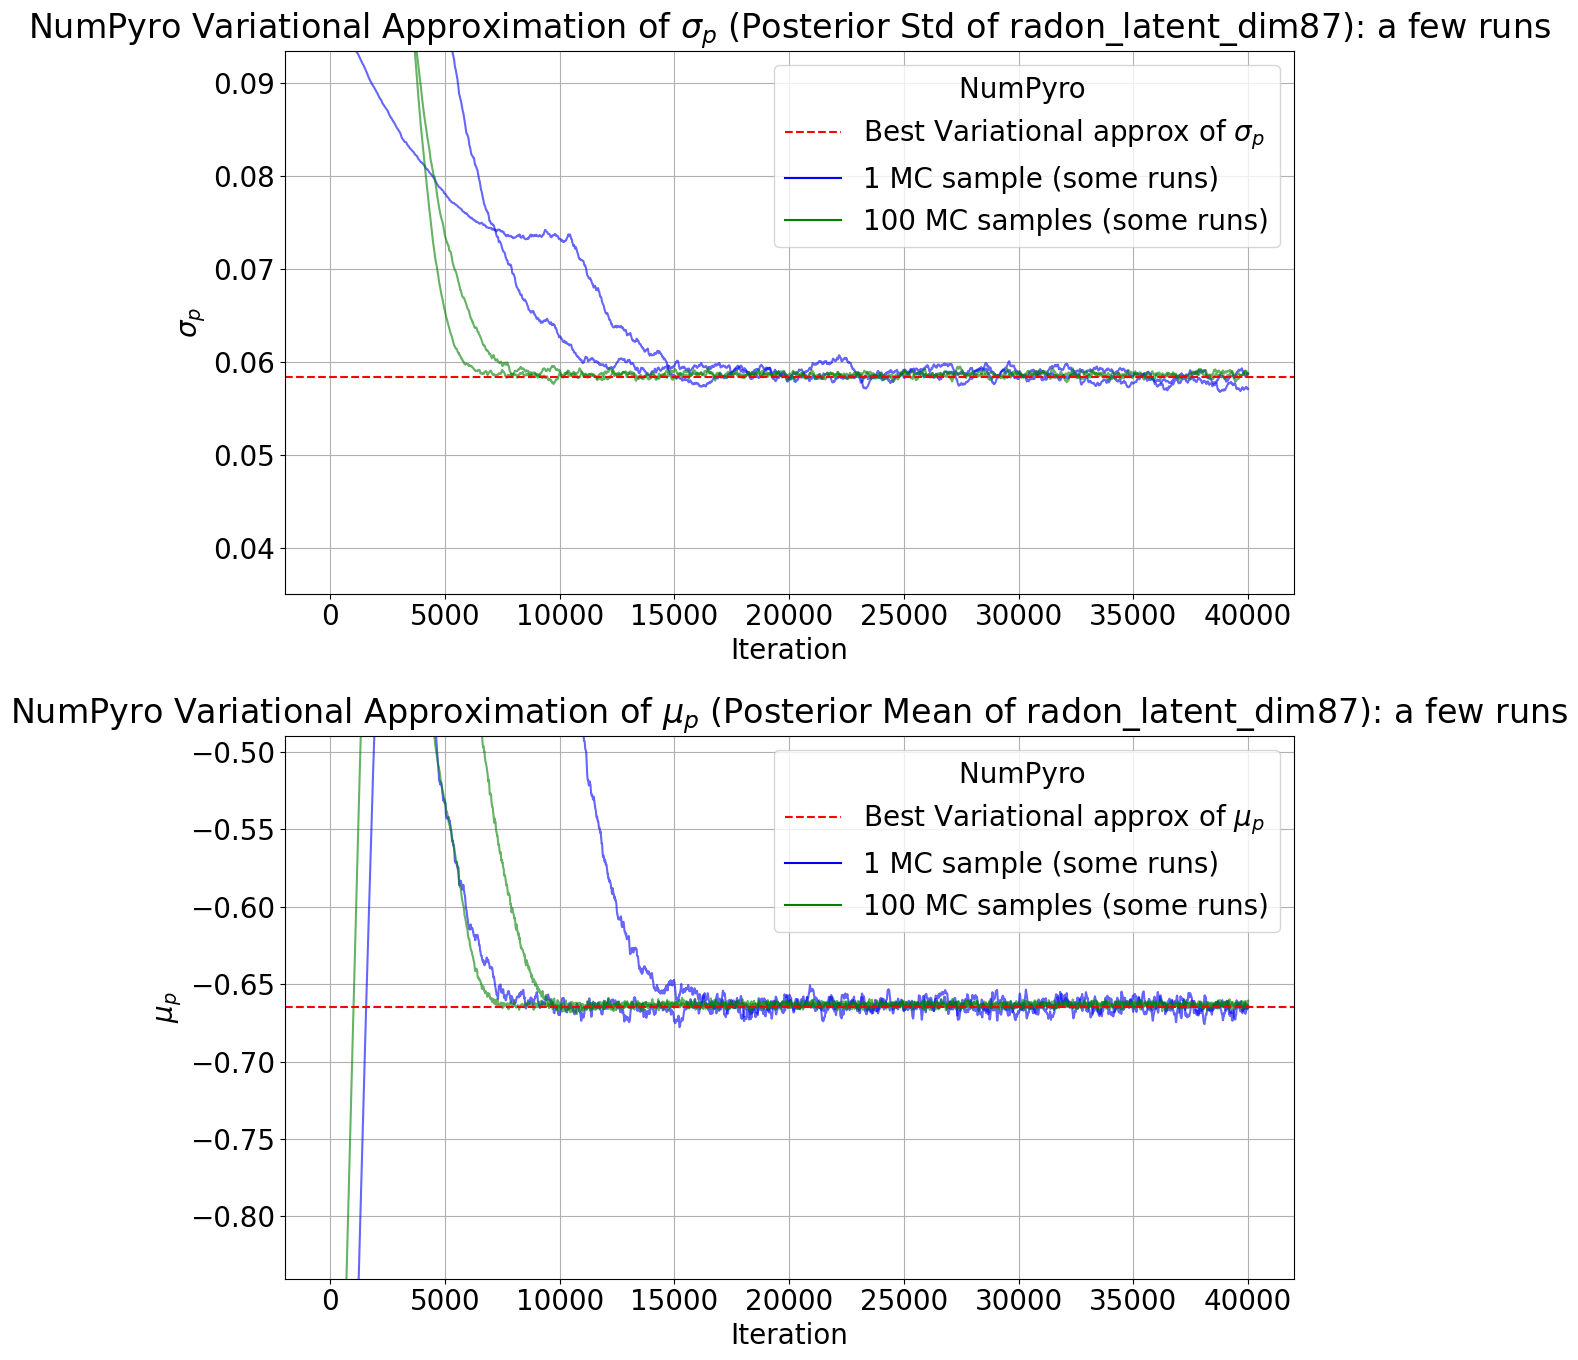

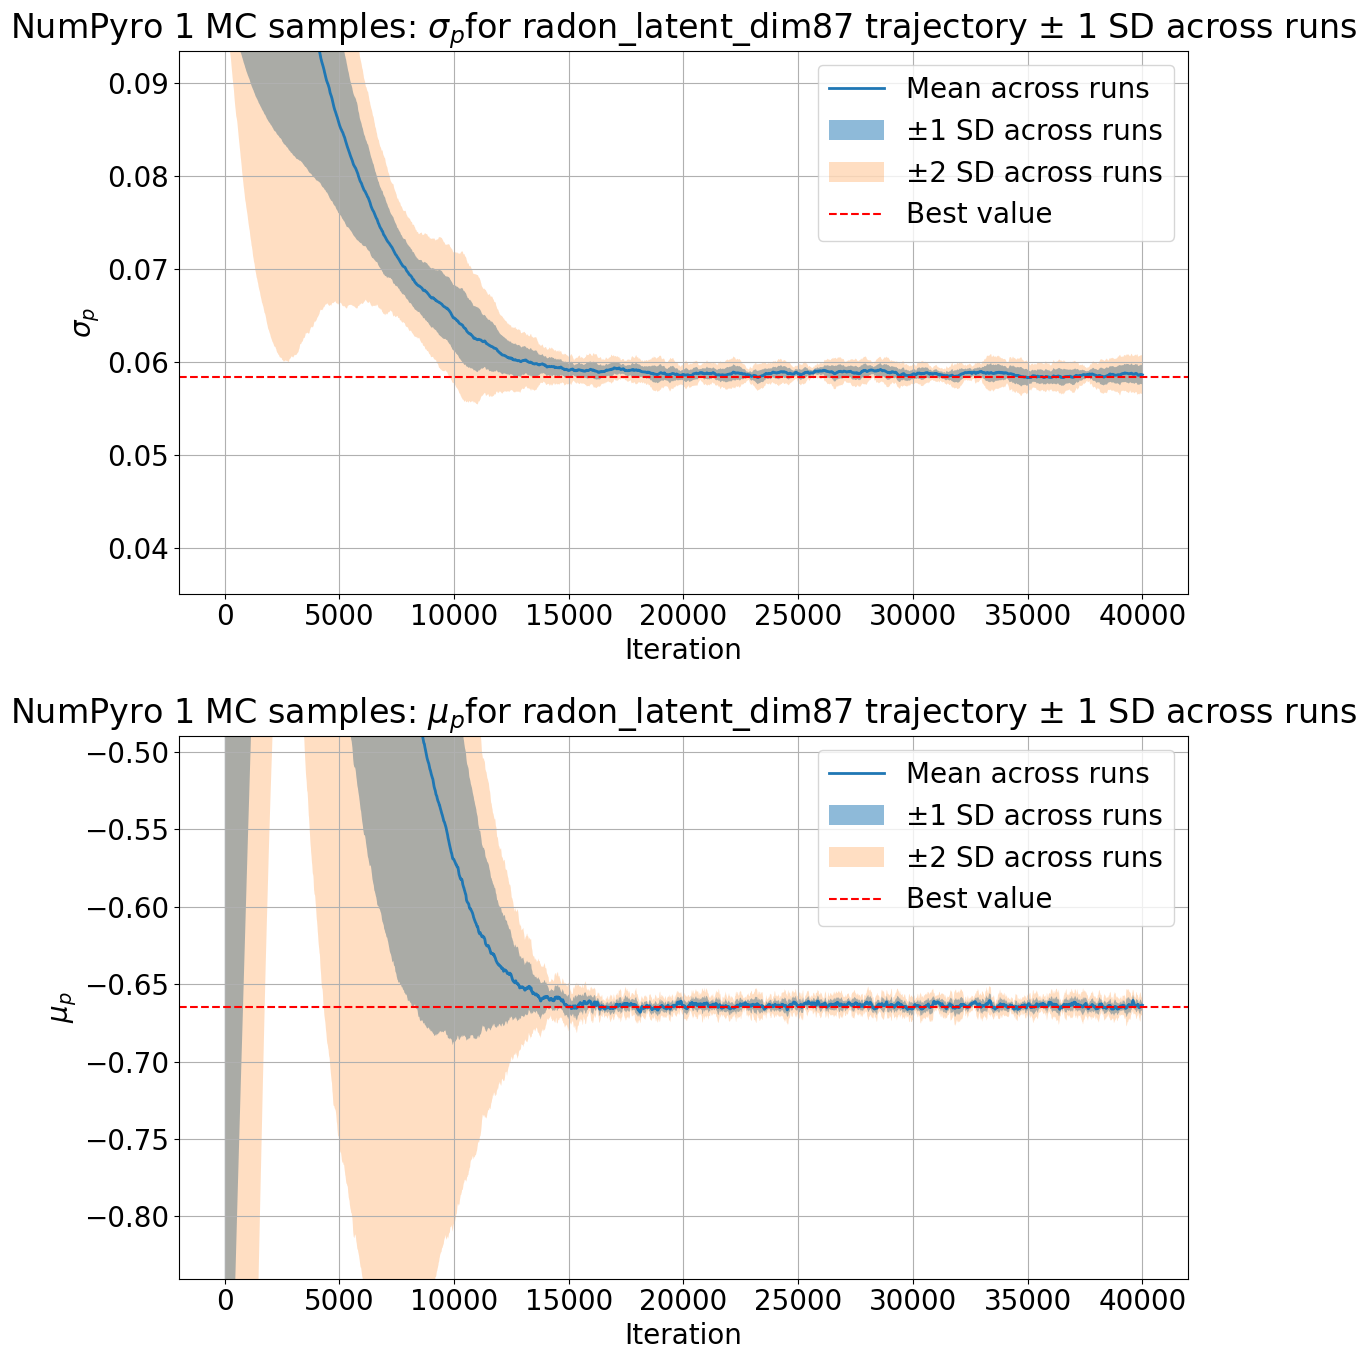

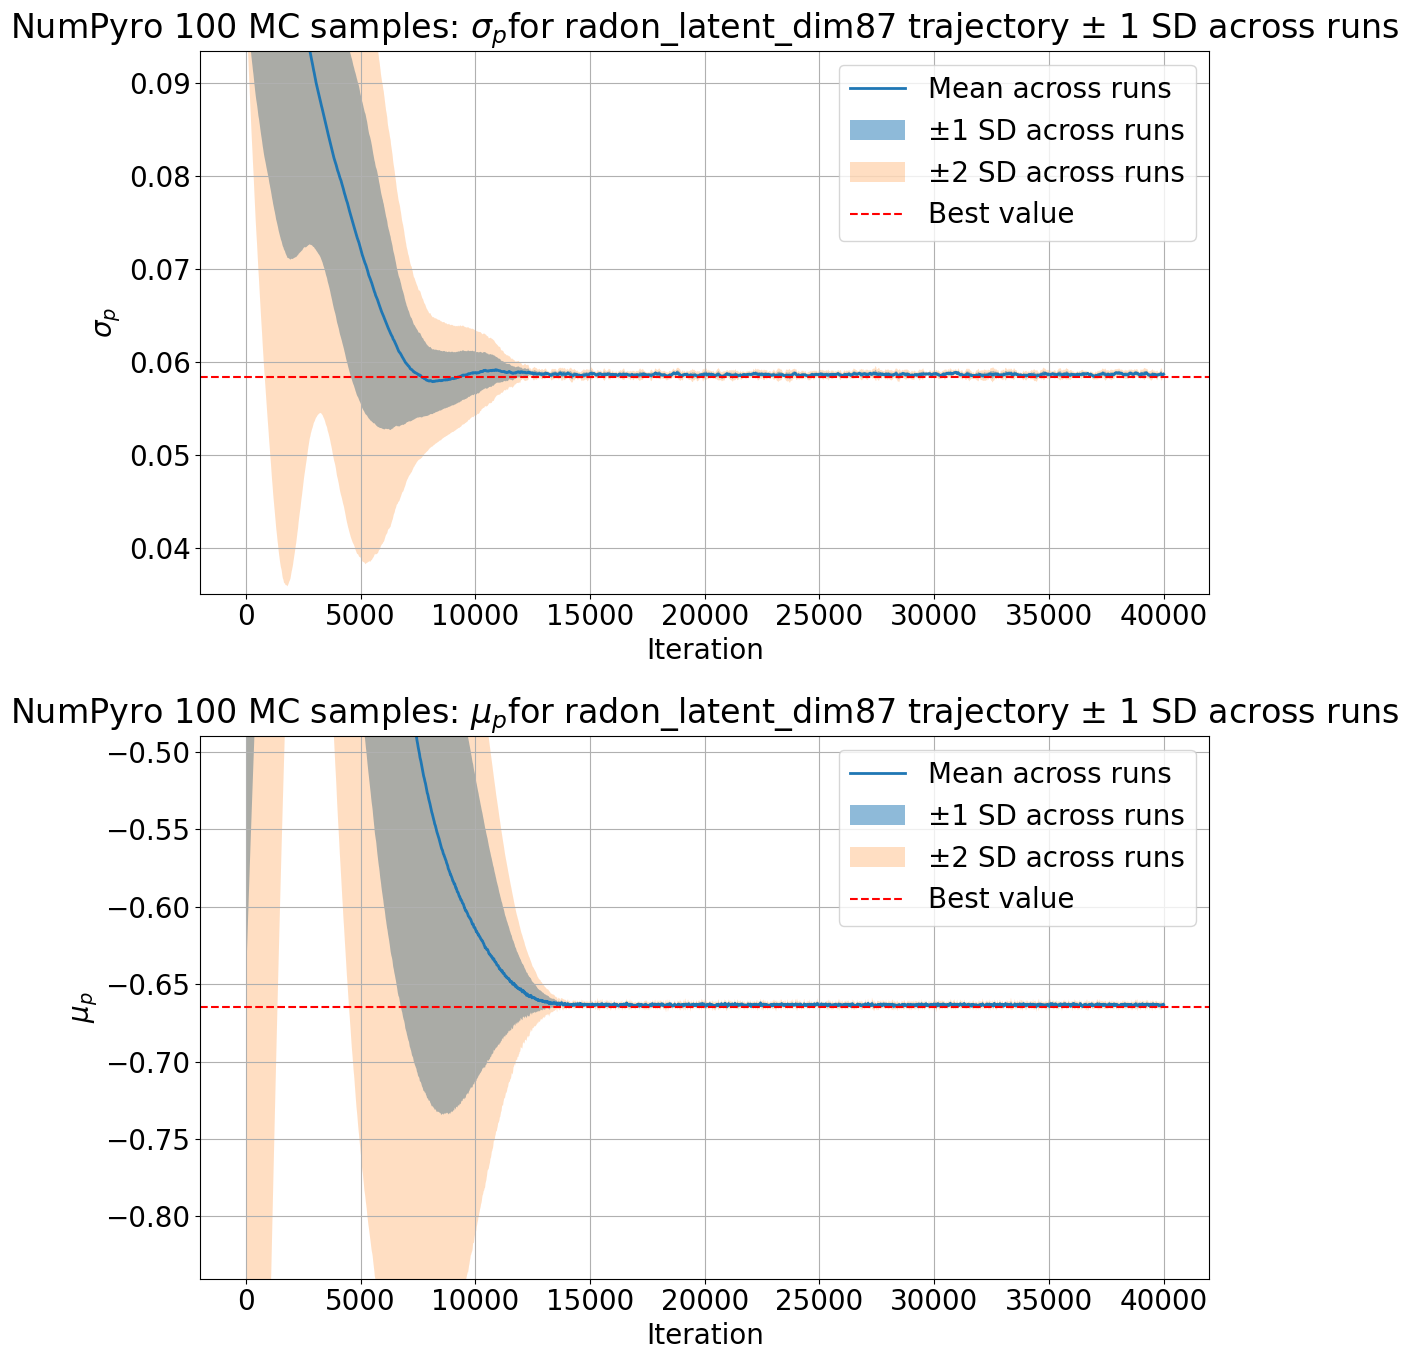

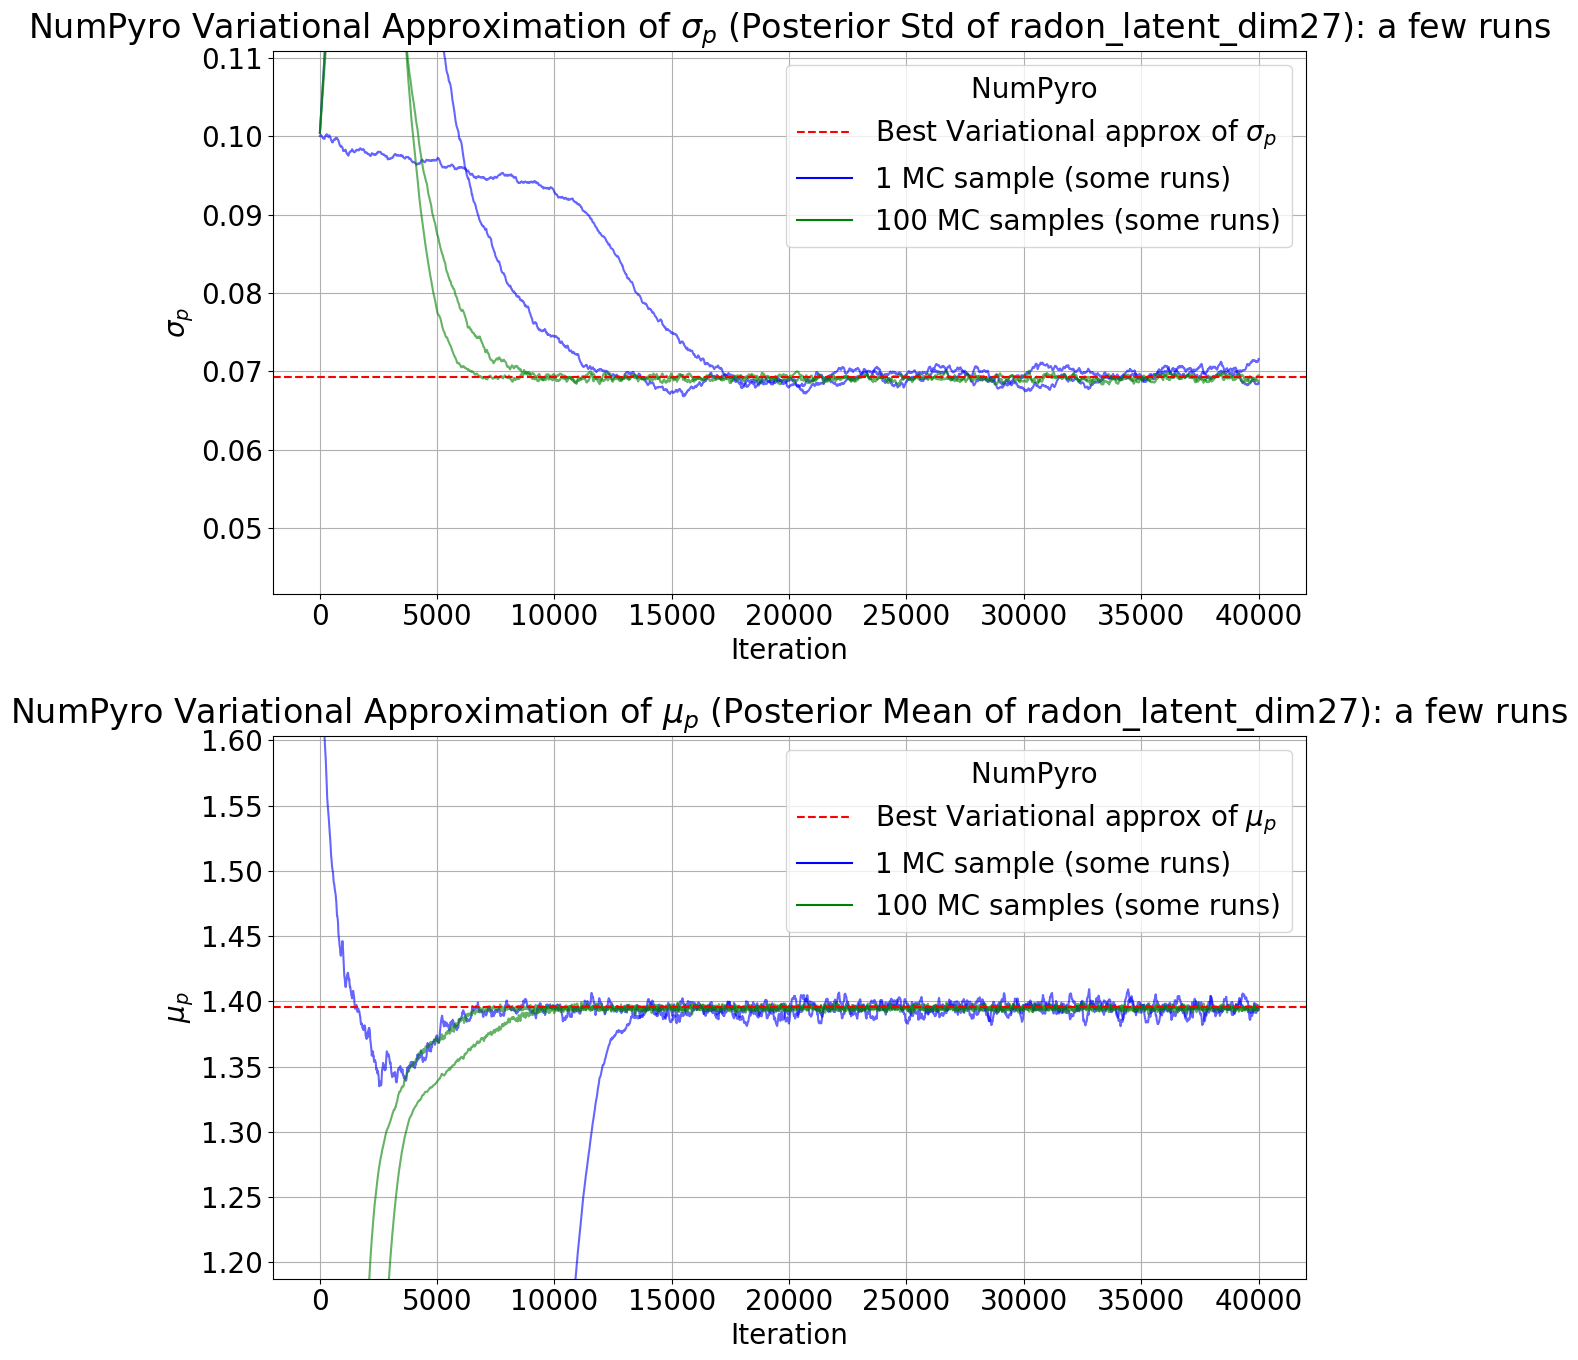

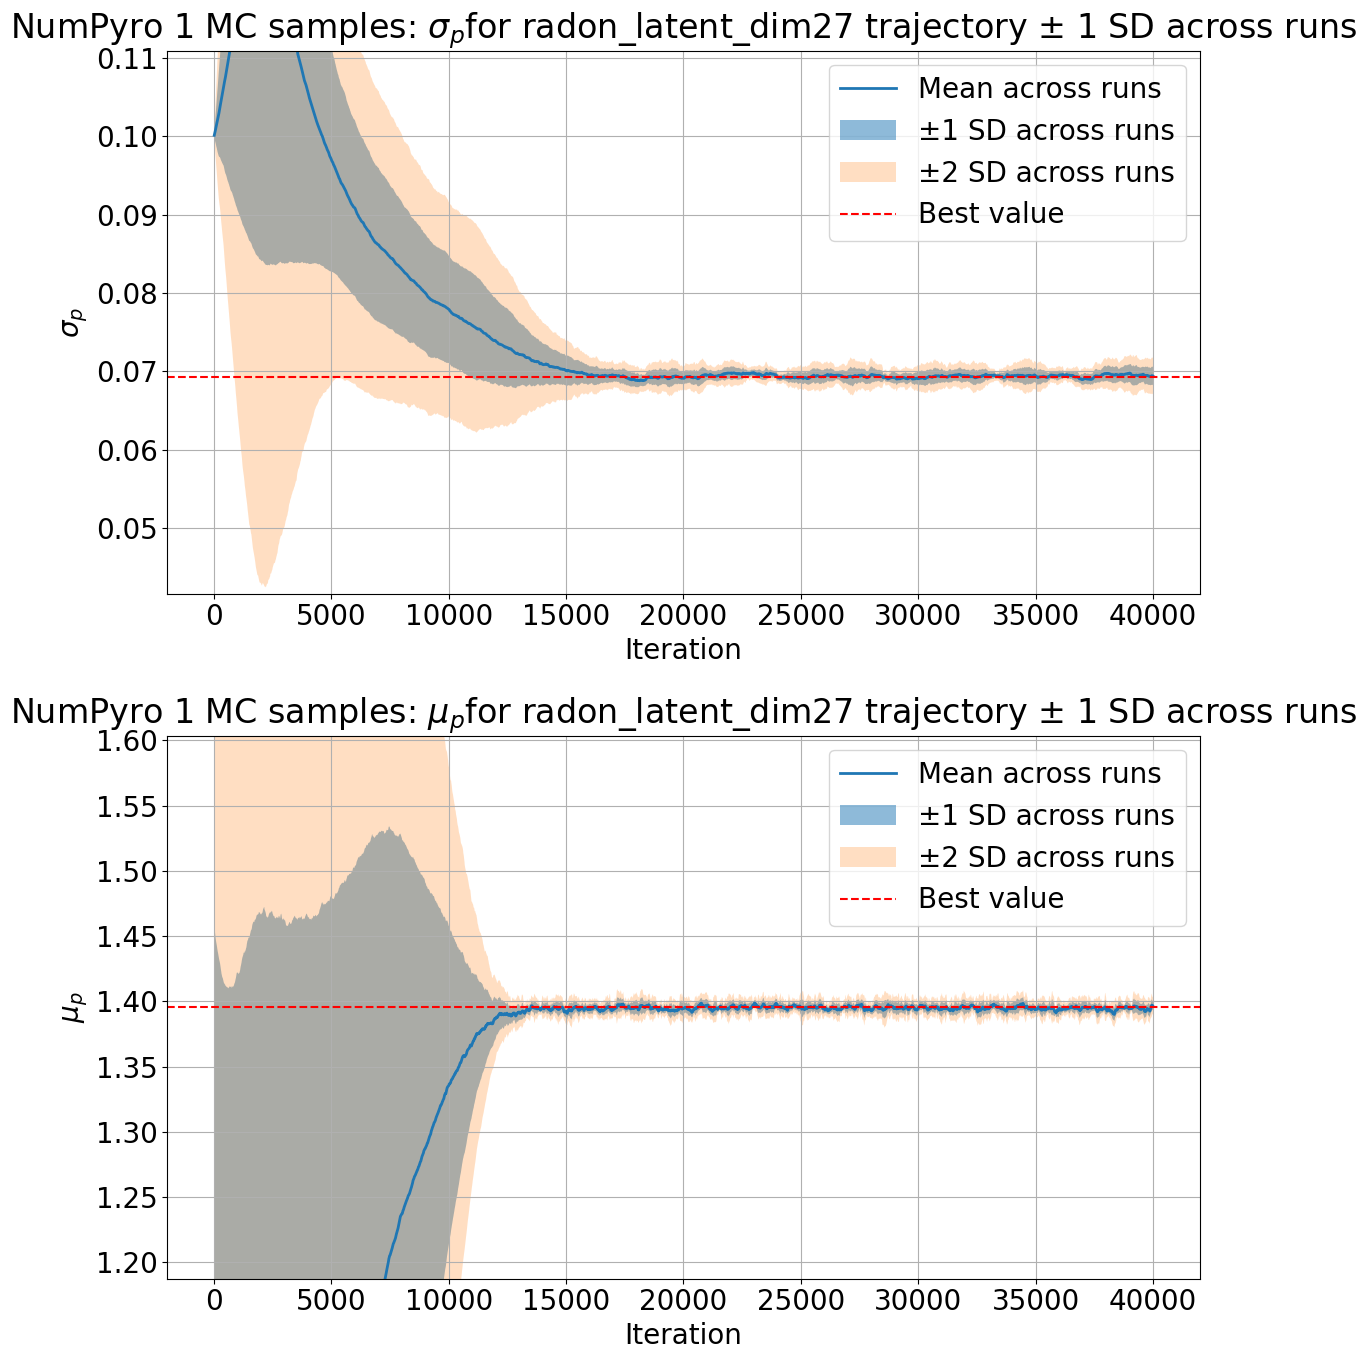

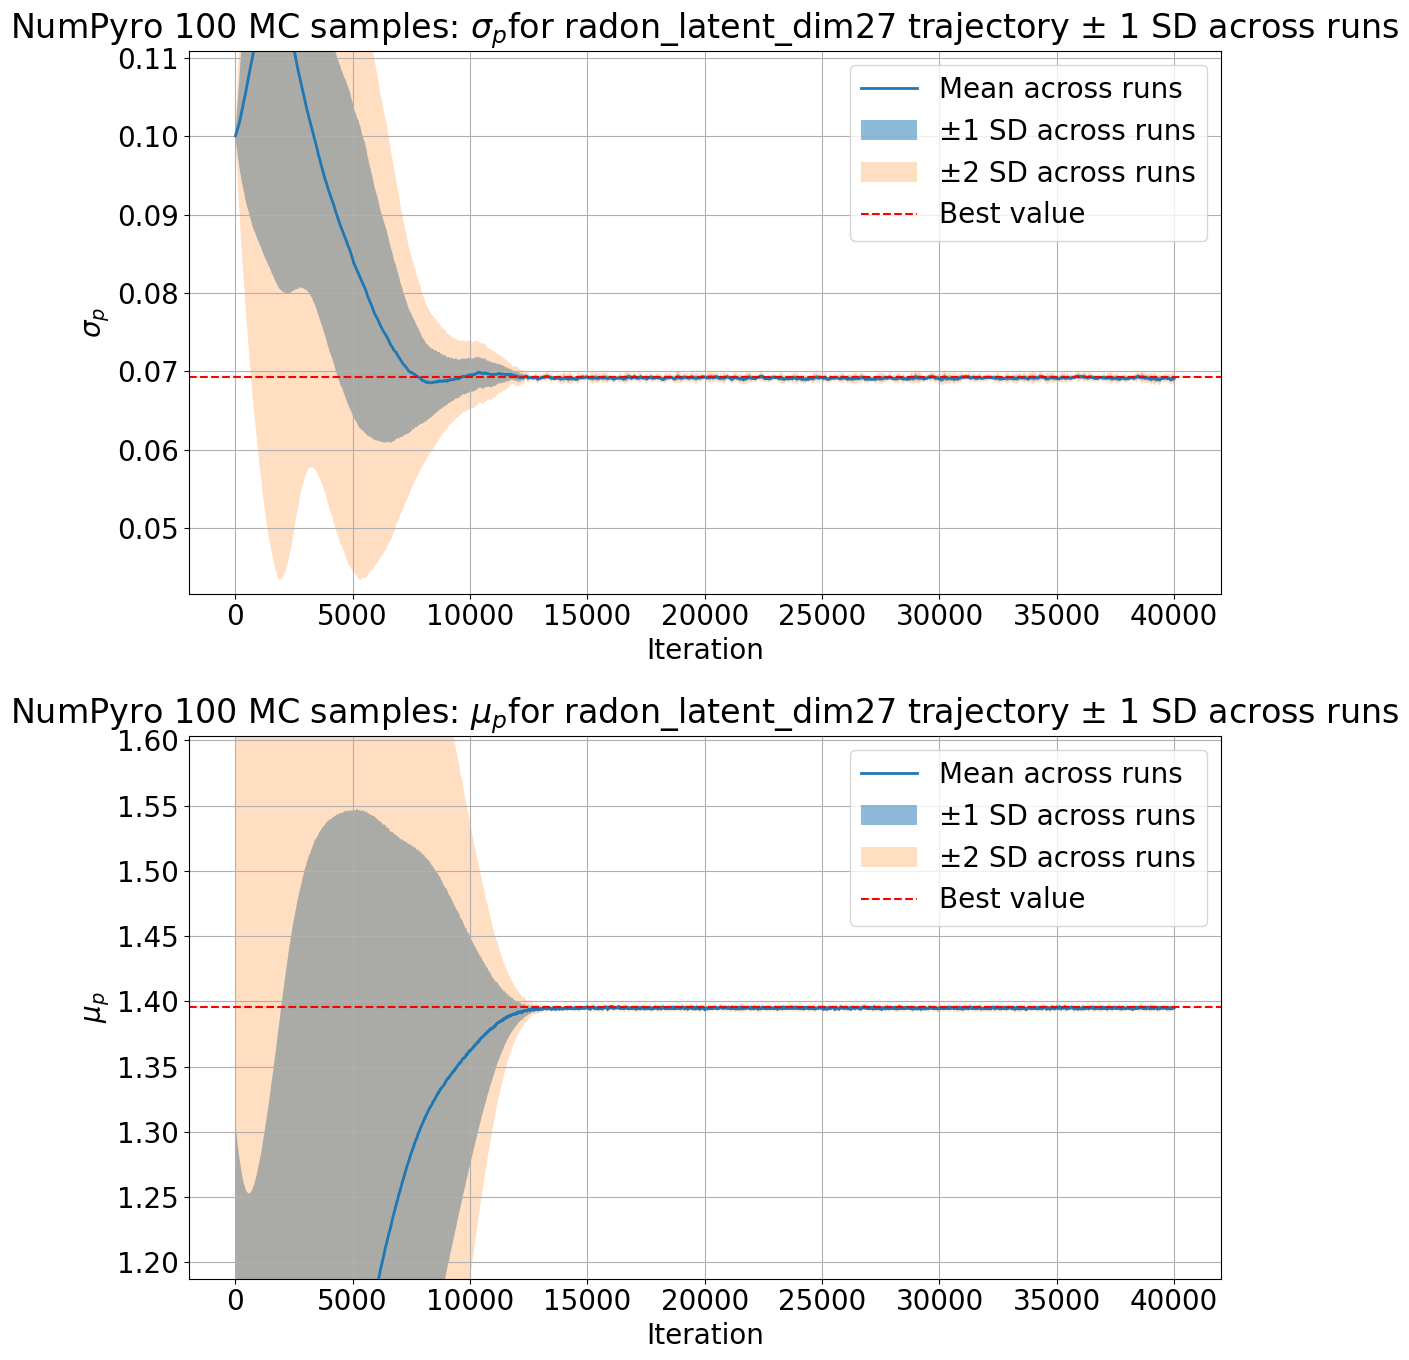

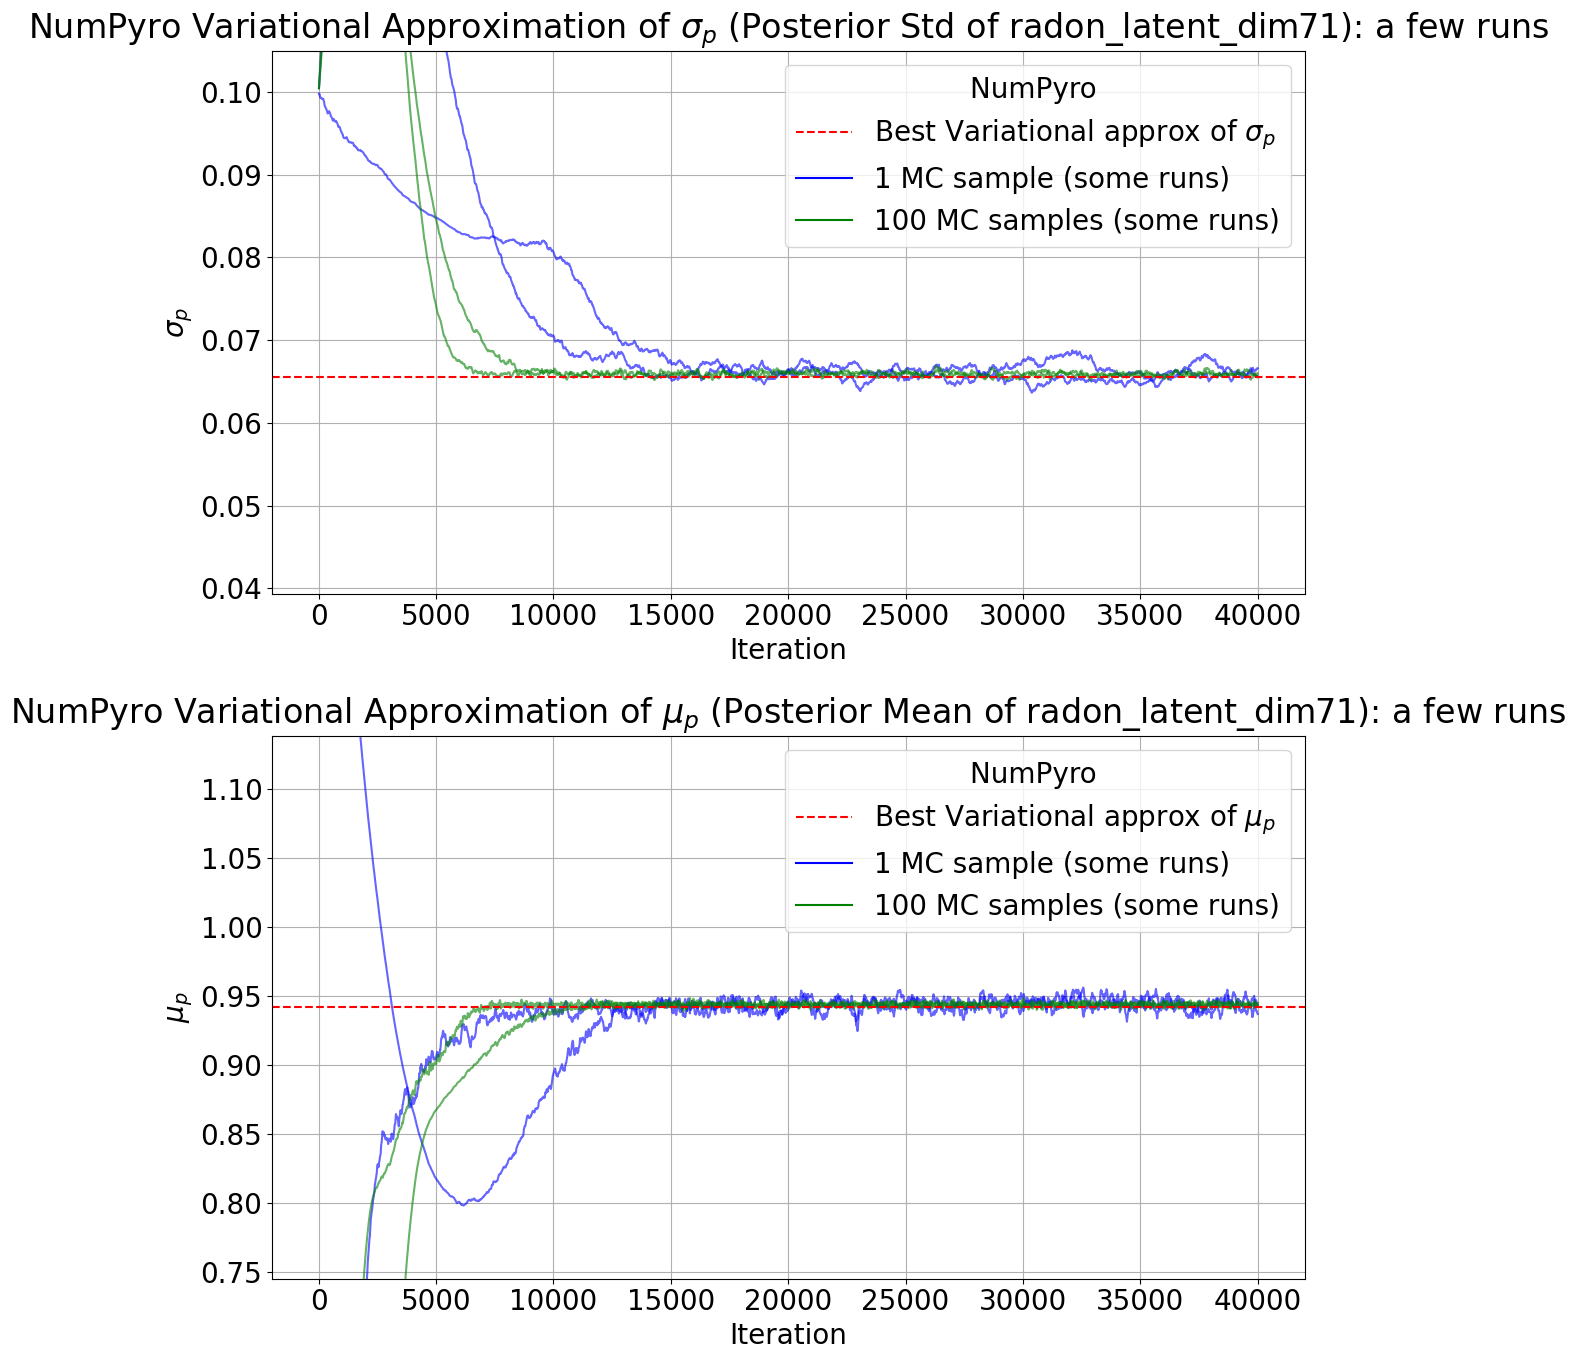

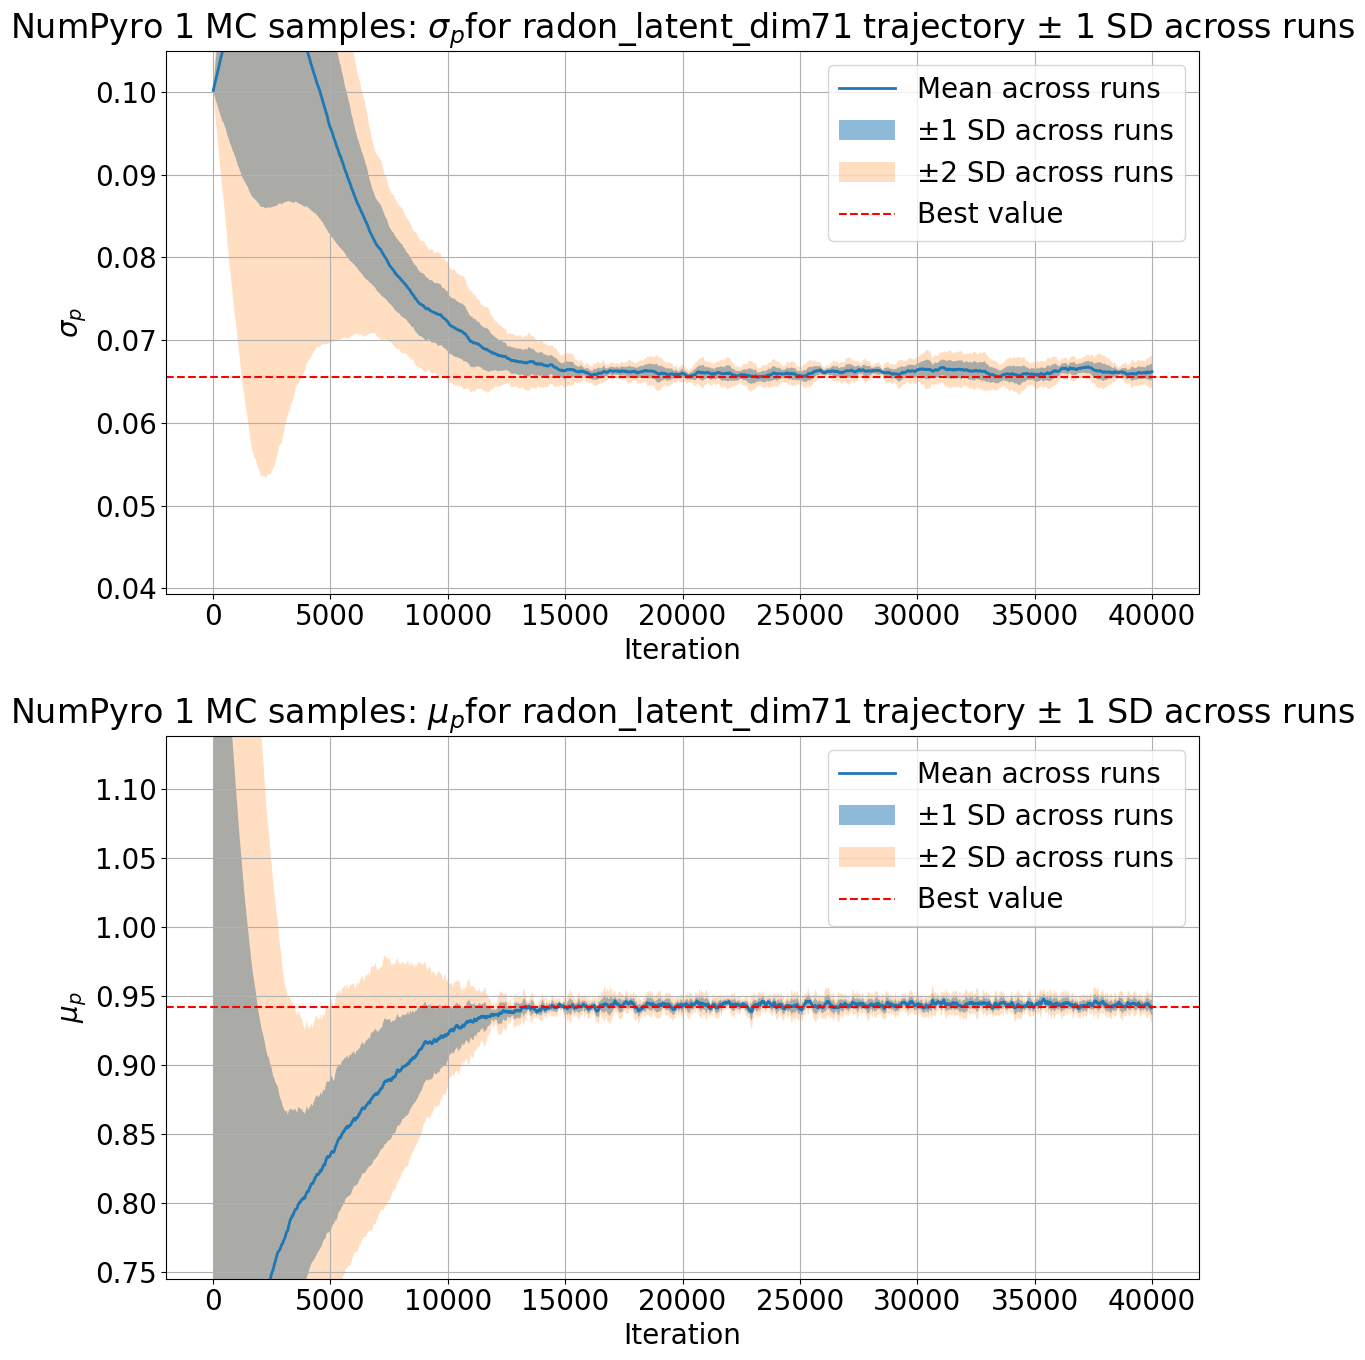

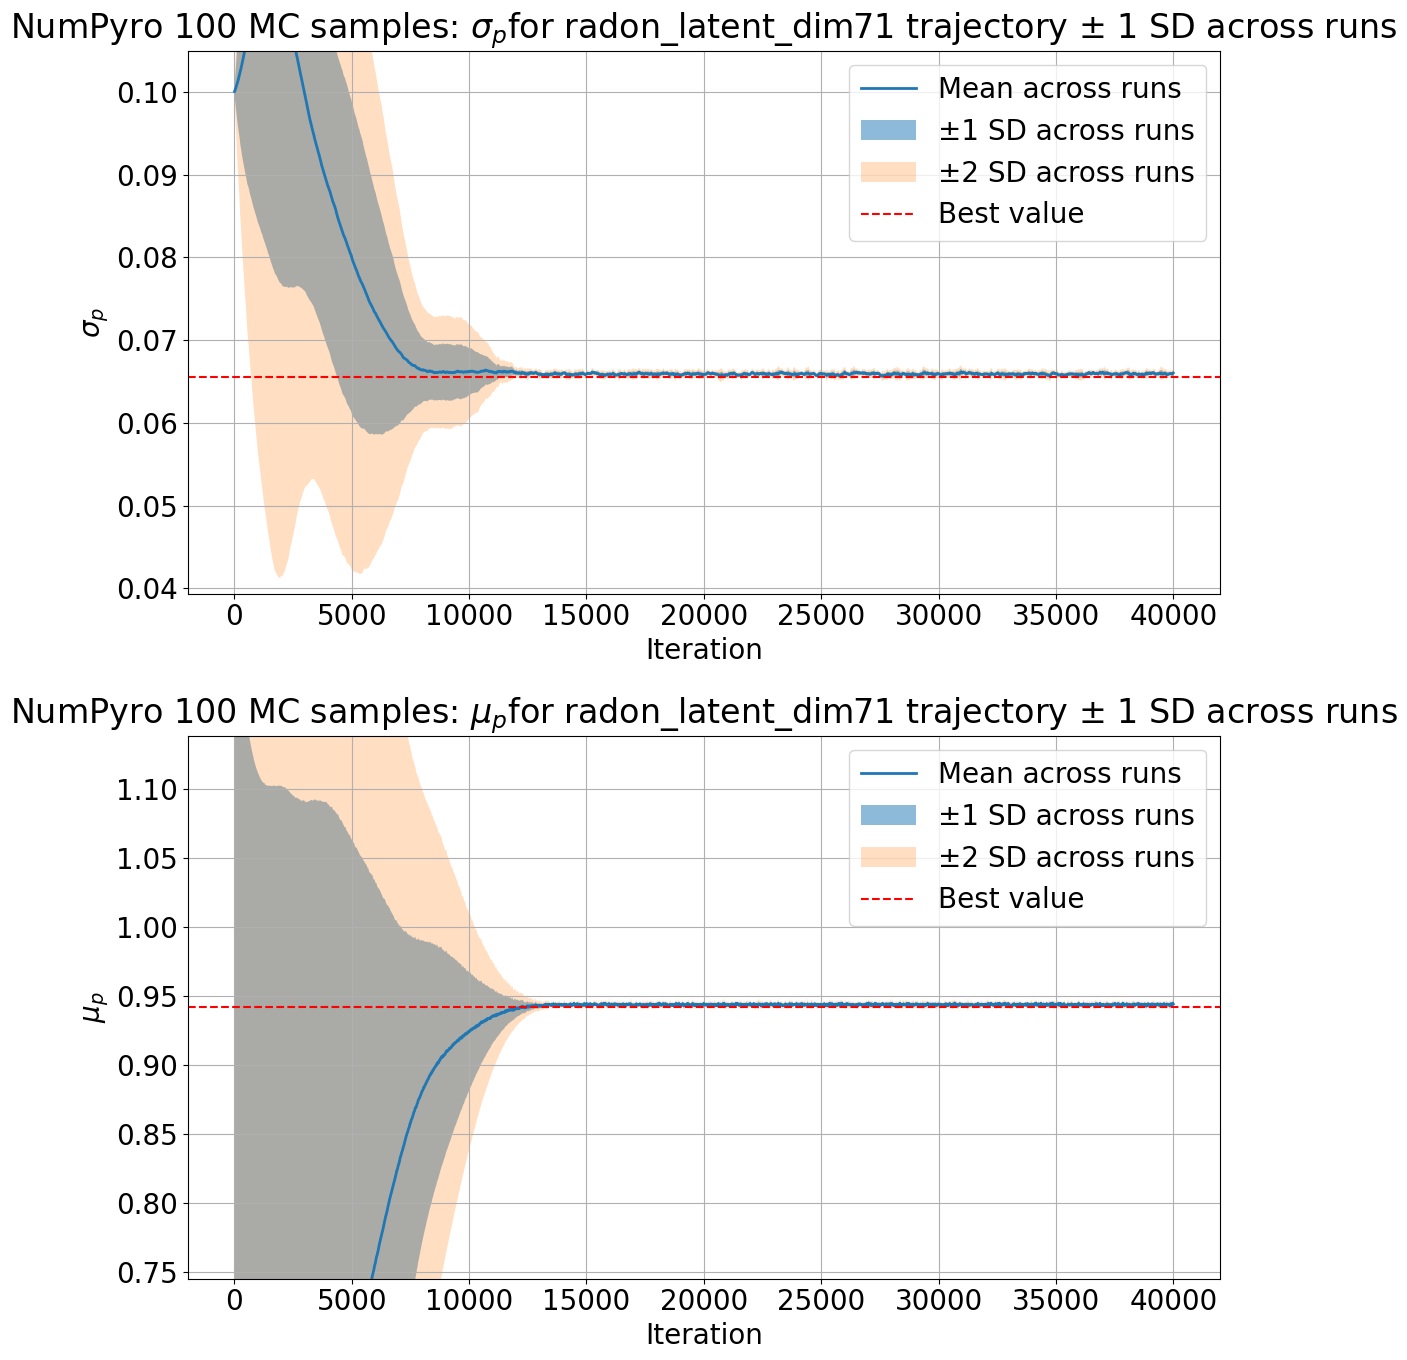

In [10]:
plot_param_names = param_names
best_by_parameter = best_reference.set_index('parameter')
best_mean = best_by_parameter.loc[plot_param_names, 'mean'].to_numpy()
best_std = best_by_parameter.loc[plot_param_names, 'sd'].to_numpy()


plot_some_dims_multid(
    single_means, single_stds, multi_means, multi_stds,
    best_mean, best_std,
    param_name='radon_latent',
    dim=len(plot_param_names),
    which_dims=which_dims,
    k=min(2, n_restarts),
    label_prefix='NumPyro ',
    iteration_stride=track_every,
)


In [ ]:
summary = pd.DataFrame({
    'parameter': param_names,
    'single_mc_final_mean': single_means[:, -1, :].mean(axis=0),
    'single_mc_final_std': single_stds[:, -1, :].mean(axis=0),
    'multi_mc_final_mean': multi_means[:, -1, :].mean(axis=0),
    'multi_mc_final_std': multi_stds[:, -1, :].mean(axis=0),
})
summary.iloc[which_dims]


In [ ]:
# Free large trajectory arrays after all summaries and plots are saved.
for _name in ['single_means', 'single_stds', 'multi_means', 'multi_stds', 'best_mean', 'best_std', 'best_by_parameter']:
    globals().pop(_name, None)
gc.collect()
